# Part V — Eigenvalues

## Trefethen & Bau, *Numerical Linear Algebra* (1997) — Lecture 24–31

这是《Numerical Linear Algebra》读书笔记的第 5 册。目标不是摘要原书，而是把每一讲整理成一份**可以独立读懂的数值线性代数讲义**，再把它映射到现代 ML systems。

每一讲尽量保持同一结构：数学对象 → 关键公式 → 几何/算法解释 → numerical stability → ML systems mapping → Python experiment。

本册自洽：下面的 setup cell 提供全部依赖，按顺序 run all 即可。

原书 PDF：https://www.stat.uchicago.edu/~lekheng/courses/309/books/Trefethen-Bau.pdf

---

**本系列共 6 册**（Trefethen & Bau, *Numerical Linear Algebra*, 40 Lectures）

| | |
|---|---|
| Part I | [Fundamentals](01_fundamentals.ipynb) |
| Part II | [QR Factorization and Least Squares](02_qr_least_squares.ipynb) |
| Part III | [Conditioning and Stability](03_conditioning_stability.ipynb) |
| Part IV | [Systems of Equations](04_systems_of_equations.ipynb) |
| Part V | [Eigenvalues](05_eigenvalues.ipynb) |
| Part VI | [Iterative Methods](06_iterative_methods.ipynb) |

索引与阅读顺序见 [00_index.ipynb](00_index.ipynb)。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import scipy.linalg as sla
    import scipy.sparse.linalg as spla
    SCIPY=True
except Exception:
    SCIPY=False
rng=np.random.default_rng(7)
np.set_printoptions(precision=5,suppress=True)

def relerr(a,b):
    return np.linalg.norm(a-b)/max(np.linalg.norm(b),1e-30)

def stable_rank(A):
    s=np.linalg.svd(A,compute_uv=False)
    return np.sum(s*s)/(s[0]*s[0])

def spectral_norm_power(A,steps=30,seed=0):
    r=np.random.default_rng(seed)
    v=r.normal(size=A.shape[1])
    v/=np.linalg.norm(v)
    for _ in range(steps):
        v=A.T@(A@v)
        v/=np.linalg.norm(v)
    return np.linalg.norm(A@v)

def make_cond(n,kappa,seed=0):
    r=np.random.default_rng(seed)
    Q1,_=np.linalg.qr(r.normal(size=(n,n)))
    Q2,_=np.linalg.qr(r.normal(size=(n,n)))
    s=np.geomspace(1,1/kappa,n)
    return Q1@np.diag(s)@Q2.T

print(f'NumPy {np.__version__} | SciPy {SCIPY}')

NumPy 2.4.2 | SciPy True


## Notation / 贯穿全书的符号

我们主要讨论实矩阵；复数情形把转置 $A^T$ 换成共轭转置 $A^*$。

- $A\in\mathbb{R}^{m\times n}$
- 向量 2-norm：

$$
\Vert x\Vert_2=\sqrt{x^Tx}
$$

- induced matrix 2-norm：

$$
\Vert A\Vert_2=\max_{x\neq0}\frac{\Vert Ax\Vert_2}{\Vert x\Vert_2}=\sigma_{\max}(A)
$$

- Frobenius norm：

$$
\Vert A\Vert_F^2=\sum_{ij}a_{ij}^2=\sum_i\sigma_i^2
$$

- condition number：

$$
\kappa_2(A)=\Vert A\Vert_2\Vert A^{-1}\Vert_2
=\frac{\sigma_{\max}}{\sigma_{\min}}
$$

- unit roundoff：记为 $u$。典型 floating-point model：

$$
\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta),\qquad |\delta|\lesssim u.
$$

计算机算一次加减乘除，不会得到精确的 $a\circ b$，而是得到一个带相对误差的结果。逐项：

- $\mathrm{fl}(\cdot)$：floating-point，机器实际算出来的数；
- $a\circ b$：一次精确运算（$\circ$ 是 $+,-,\times,/$）；
- $\delta$：这次运算引入的相对误差；
- $u$：unit roundoff，这种格式「一次正确舍入」的相对误差上限。

左边是机器结果，右边是「真值再乘 $1+\delta$」。约束的是**相对误差**，不是绝对误差：真值若是 $1.0$，FP32 下次运算大约落在 $1\pm 6\times 10^{-8}$，不会无缘无故错到 $1.01$。

常见 $u$：

- FP32：$u\approx 2^{-24}\approx 6\times 10^{-8}$
- FP16：$u\approx 2^{-11}\approx 5\times 10^{-4}$
- BF16：$u\approx 2^{-8}\approx 4\times 10^{-3}$

一次运算只错 $u$。病态问题可能把这个 $u$ 放大成 $\kappa u$ 量级的解误差。所以不要把「格式很粗」「矩阵很病态」「算法多放大了 rounding」三件事混成一句“数值不稳”。

### 区分

不要把下面三个问题混在一起：

1. **operator amplification**：$\Vert A\Vert$ 大不大？
2. **problem conditioning**：$A^{-1}$ 是否敏感？
3. **algorithm stability**：实现是否额外放大 rounding error？

现代 ML numerics 中，大量争论其实是把这三个层次混在了一起。

# Lecture 24 — Eigenvalue Problems

### 1. Eigenvalue 与 invariant direction

$$
Ax=\lambda x.
$$

若 $A=X\Lambda X^{-1}$，则

$$
A^k=X\Lambda^kX^{-1}.
$$

所以 eigenvalues 控制 repeated application 的 asymptotic behavior，但前提是 eigenvector basis 的 conditioning 不能太坏。

### 2. Normal vs non-normal

Normal matrix 满足

$$
A^TA=AA^T
$$

（实数情形）。Normal matrix 可由 orthogonal/unitary basis diagonalize，因此 eigenvectors condition 很好。

Non-normal matrix 则可能出现：eigenvalues 全部看似温和，但 singular values 很大，短时间 perturbation 被巨大放大。

### 3. Hessian vs Jacobian

Hessian $H=H^T$ 是 symmetric，因此 eigenvalues 直接等于 signed curvature directions：

$$
v^THv=\lambda\Vert v\Vert^2.
$$

一般 Jacobian/weight matrix 不 symmetric，因此若问题是“最大 perturbation gain”，应看 singular values。

In [19]:
A=np.array([[1.,100.],[0.,1.]])
print(f'eigenvalues {np.linalg.eigvals(A)}')
print(f'singular values {np.linalg.svd(A, compute_uv=False)}')
v=np.array([0.,1.])
print(f'||v|| {np.linalg.norm(v)} ||Av|| {np.linalg.norm(A @ v)}')

eigenvalues [1. 1.]
singular values [100.01   0.01]
||v|| 1.0 ||Av|| 100.00499987500625


**ML numerics 自测**

**Q1.** eigenvalue 控制什么，前提是什么？

**A.** $A=X\Lambda X^{-1}$ 则 $A^k=X\Lambda^k X^{-1}$。谱控制反复作用的渐近行为，前提是 eigenvector basis 的 conditioning 不能太坏。

**Q2.** normal 和 non-normal 差在哪？

**A.** normal：$A^TA=AA^T$，可用正交基底对角化，特征向量条件好。non-normal：特征值看起来温和，singular value 仍可很大，短时扰动被猛放大。

**Q3.** 看 Hessian 该看特征值，看一般 weight/Jacobian 该看什么？

**A.** Hessian 对称，$v^THv=\lambda\Vert v\Vert^2$，特征值就是有符号曲率。一般矩阵若问最大扰动增益，看 singular values。

**Q4.** 只报 eigenvalues 够不够判断“会不会炸”？

**A.** non-normal 时不够。还要看 $\sigma_{\max}$ / transient growth。


# Lecture 25 — Overview of Eigenvalue Algorithms

### 1. 为什么 eigenproblem 没有一个通吃算法

你想要的 spectral information 不同，算法也不同：

- dominant eigenvalue：power iteration；
- target near $\mu$：inverse/shift-invert；
- dense all eigenvalues：Hessenberg + QR；
- huge sparse/operator top few：Arnoldi；
- huge symmetric top few：Lanczos。

### 2. Power iteration

若

$$
A=V\Lambda V^{-1},\qquad
x_0=\sum_i c_iv_i,
$$

那么

$$
A^kx_0=\sum_i c_i\lambda_i^kv_i.
$$

若 $|\lambda_1|>|\lambda_2|$，归一化后 dominant component 比例大约按

$$
\left|\frac{\lambda_2}{\lambda_1}\right|^k
$$

衰减。

### 3. ML mapping

如果只是需要 top Hessian eigenvalue，full eigendecomposition 是完全错误的复杂度选择。matrix-free HVP + power/Lanczos 才是正确 primitive。

**ML numerics 自测**

**Q1.** 为什么没有一个通吃的 eigen 算法？

**A.** 要的谱信息不同：dominant 用 power；靠近 $\mu$ 用 inverse/shift-invert；dense 全谱用 Hessenberg+QR；超大 sparse 用 Arnoldi/Lanczos。

**Q2.** power iteration 的收敛比是什么？

**A.** $A^kx_0=\sum c_i\lambda_i^k v_i$。$|\lambda_1|>|\lambda_2|$ 时，次分量按 $|\lambda_2/\lambda_1|^k$ 衰减。

**Q3.** 只要 top Hessian eigenvalue，该不该 full eigendecomposition？

**A.** 不该。正确 primitive 是 matrix-free HVP + power/Lanczos。

**Q4.** 选算法前先问哪五个问题？

**A.** symmetric? dense 还是 operator-only? 全部还是几个? extremal 还是 interior? 是否允许线性 solve?


# Lecture 26 — Reduction to Hessenberg or Tridiagonal Form

### 1. Similarity transformation

$$
B=Q^TAQ
$$

与 $A$ similar，因此 characteristic polynomial 相同：

$$
\det(B-\lambda I)=\det(Q^T(A-\lambda I)Q)=\det(A-\lambda I).
$$

所以 eigenvalues 不变。

### 2. Hessenberg reduction

对 general dense $A$，通过 Householder similarity transformations 把它变成 upper Hessenberg：

$$
H_{ij}=0\quad \text{for } i>j+1.
$$

后续 QR iteration 的每一步因此从 $O(n^3)$ 降到 $O(n^2)$ 量级。

### 3. Symmetric case

若 $A=A^T$，Hessenberg + symmetry 直接意味着 tridiagonal：

$$
T=Q^TAQ.
$$

### 4. ML mapping

Lanczos 的本质就是“不显式构造巨大 $Q$ 完整 reduction，而逐步构造一个小 tridiagonal projection”。这就是 Hessian spectrum diagnostics 为什么可做。

In [20]:
A=rng.normal(size=(8,8))
if SCIPY:
    H,Q=sla.hessenberg(A,calc_q=True)
    print(f'similarity residual {relerr(Q.T @ A @ Q, H)} below subdiagonal {np.linalg.norm(np.tril(H, -2))}')
else: print(f'SciPy unavailable')

similarity residual 3.883945338932625e-16 below subdiagonal 0.0


**ML numerics 自测**

**Q1.** similarity $B=Q^TAQ$ 保住了什么？

**A.** $\det(B-\lambda I)=\det(A-\lambda I)$，特征值不变。它是换坐标，不是换问题。

**Q2.** Hessenberg reduction 的计算目的是什么？

**A.** 用 Householder similarity 把 dense $A$ 变成 $i>j+1$ 处为 0。后续 QR 每步从 $O(n^3)$ 降到 $O(n^2)$。

**Q3.** 对称情形为什么变成三对角？

**A.** $A=A^T$ 时 Hessenberg + 对称 $\Rightarrow$ tridiagonal $T=Q^TAQ$。

**Q4.** Lanczos 和这次 reduction 是什么关系？

**A.** Lanczos 不显式构造巨大完整 $Q$，而是逐步做一个小三对角投影。所以 Hessian spectrum 诊断才做得起。


# Lecture 27 — Rayleigh Quotient, Inverse Iteration

### 1. Rayleigh quotient

$$
\rho(x)=\frac{x^TAx}{x^Tx}.
$$

若 $A=A^T=Q\Lambda Q^T$，写

$$
x=\sum_i c_iq_i,
$$

则

$$
\rho(x)=\frac{\sum_i\lambda_i c_i^2}{\sum_i c_i^2},
$$

所以它是 eigenvalues 的加权平均，必在 $[\lambda_{\min},\lambda_{\max}]$ 中。

### 2. Directional curvature

对 Hessian $H$，

$$
\frac{v^THv}{v^Tv}
$$

就是方向 $v$ 上的 normalized curvature。

### 3. Inverse iteration

为找靠近 shift $\mu$ 的 eigenvalue，反复解

$$
(A-\mu I)y_k=x_k,
\qquad
x_{k+1}=y_k/\Vert y_k\Vert.
$$

因为 $(A-\mu I)^{-1}$ 的 eigenvalues 是

$$
\frac1{\lambda_i-\mu},
$$

离 $\mu$ 最近的 eigenvalue 被变成 magnitude 最大的方向。

### 4. Numerical catch

shift 越接近 target，linear system 越 ill-conditioned。算法强大恰恰是因为它把目标方向变成 near-singular solve，因此 solver accuracy 变得关键。

In [21]:
n=40
Q,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.linspace(1,20,n)
A=Q@np.diag(ev)@Q.T
mu=10.3
x=rng.normal(size=n)
x/=np.linalg.norm(x)
h=[]
for _ in range(8):
    y=np.linalg.solve(A-mu*np.eye(n),x)
    x=y/np.linalg.norm(y)
    h.append(x@(A@x))
print(f'shift {mu} Rayleigh sequence {np.array(h)} nearest exact {ev[np.argmin(abs(ev - mu))]}')

shift 10.3 Rayleigh sequence [10.25648 10.25641 10.25641 10.25641 10.25641 10.25641 10.25641 10.25641] nearest exact 10.256410256410255


**ML numerics 自测**

**Q1.** Rayleigh quotient $\rho(x)=x^TAx/x^Tx$ 落在哪？

**A.** 对称时它是特征值的加权平均，必在 $[\lambda_{\min},\lambda_{\max}]$。对 Hessian，它就是方向 $v$ 上的归一化曲率。

**Q2.** inverse iteration 为什么能锁定靠近 $\mu$ 的特征值？

**A.** 反复解 $(A-\mu I)y=x$ 再归一化。$(A-\mu I)^{-1}$ 的特征值是 $1/(\lambda_i-\mu)$，离 $\mu$ 最近的变成最大增益方向。

**Q3.** 这个算法最危险的中间步骤是什么？

**A.** shift 越准，线性系统越病态。它正是靠 near-singular solve 工作，所以 solver 精度变成瓶颈。

**Q4.** ML 里用 Rayleigh / inverse iteration 时该盯什么？

**A.** 方向曲率 $v^THv/v^Tv$，以及 $(H-\mu I)$ solve 的 residual / $\kappa$。


# Lecture 28 — QR Algorithm without Shifts

### 1. Unshifted QR iteration

从 $A_0=A$ 开始：

$$
A_k=Q_kR_k,
\qquad
A_{k+1}=R_kQ_k.
$$

注意

$$
A_{k+1}=Q_k^TA_kQ_k,
$$

所以每一步都是 similarity transformation，eigenvalues 不变。

### 2. 与 simultaneous iteration 的联系

累积

$$
\bar Q_k=Q_0Q_1\cdots Q_k,
$$

QR iteration 可以理解为不断把 basis 对齐到 invariant subspaces，然后把 $A$ 在这个 basis 下逐步变成 triangular/diagonal form。

### 3. Convergence

当 eigenvalue magnitude separation 较好时，subdiagonal entries 逐渐变小。没有 shift 时速度可能非常慢，尤其相邻 eigenvalues 很接近。

QR diagonal [5.02803 2.39258 1.57939] exact [1.57939 2.39258 5.02803]


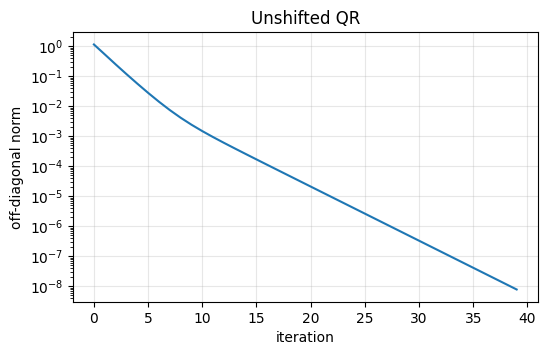

In [22]:
A=np.array([[4.,1.,1.],[1.,3.,.5],[1.,.5,2.]])
Ak=A.copy()
off=[]
for _ in range(40):
    Q,R=np.linalg.qr(Ak)
    Ak=R@Q
    off.append(np.linalg.norm(Ak-np.diag(np.diag(Ak))))
print(f'QR diagonal {np.diag(Ak)} exact {np.linalg.eigvalsh(A)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(off)
plt.xlabel('iteration')
plt.ylabel('off-diagonal norm')
plt.title('Unshifted QR')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** unshifted QR iteration 为什么不改变特征值？

**A.** $A_k=Q_kR_k$、$A_{k+1}=R_kQ_k=Q_k^TA_kQ_k$，每步都是 similarity。

**Q2.** 它在几何上在对齐什么？

**A.** 累积 $\bar Q_k=Q_0\cdots Q_k$，把 basis 对齐到 invariant subspace，使 $A$ 在该坐标下逐步变成三角/对角。

**Q3.** 没有 shift 时什么情况会极慢？

**A.** 相邻 $|\lambda|$ 很接近、magnitude separation 差。subdiagonal 缩小可以非常慢。

**Q4.** 该看对角收敛还是该看 off-diagonal？

**A.** 看 off-diagonal / subdiagonal norm 是否在掉。对角接近还不够，没 deflation 就不算拆开。


# Lecture 29 — QR Algorithm with Shifts

### 1. Shifted QR

选择 shift $\mu_k$：

$$
A_k-\mu_kI=Q_kR_k,
$$

然后

$$
A_{k+1}=R_kQ_k+\mu_kI.
$$

仍然有

$$
A_{k+1}=Q_k^TA_kQ_k,
$$

所以 eigenvalues 仍保持不变。

### 2. 为什么 shift 加速

对于 power/inverse-type iteration，收敛速度由 eigenvalue ratios 决定。适当 shift 改变这些 ratios，使目标 eigenvalue 更快被分离。

### 3. Deflation

当某个 subdiagonal $a_{i+1,i}$ 足够小，就可以把矩阵近似拆成两个 block，分别继续做 eigen solve。现代 QR eigensolver 的效率很大程度来自 aggressive deflation + good shifts。

### 4. Engineering analogy

shift 的思想本质是“改变谱的位置，让原来困难的方向更容易被算法分辨”。这和 damping/preconditioning 虽不相同，但都在主动修改 spectral geometry。

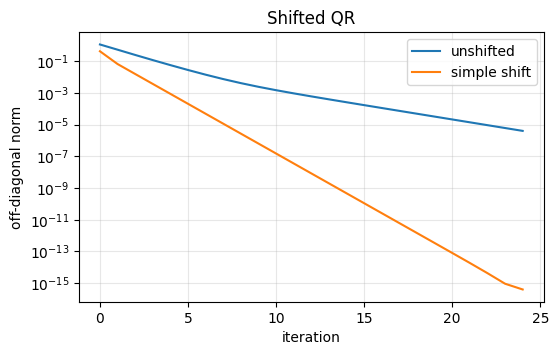

In [23]:
A=np.array([[4.,1.,1.],[1.,3.,.5],[1.,.5,2.]])
def run(A,shifted,steps=20):
    A=A.copy()
    h=[]
    for _ in range(steps):
        mu=A[-1,-1] if shifted else 0.
        Q,R=np.linalg.qr(A-mu*np.eye(3))
        A=R@Q+mu*np.eye(3)
        h.append(np.linalg.norm(A-np.diag(np.diag(A))))
    return np.array(h)
hu=run(A,False,25)
hs=run(A,True,25)
plt.figure(figsize=(6,3.5))
plt.semilogy(hu,label='unshifted')
plt.semilogy(hs,label='simple shift')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('off-diagonal norm')
plt.title('Shifted QR')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** shifted QR 还是 similarity 吗？

**A.** 是。$A_k-\mu_k I=Q_kR_k$、$A_{k+1}=R_kQ_k+\mu_k I=Q_k^TA_kQ_k$，特征值仍不变。

**Q2.** shift 为什么加速？

**A.** 它改 eigenvalue ratio，让目标特征值更快被分离。和 power/inverse iteration 是同一类谱几何操作。

**Q3.** deflation 在省什么？

**A.** subdiagonal 足够小时把矩阵拆成两个 block 分别做。现代 QR eigensolver 的效率大量来自 aggressive deflation + 好 shift。

**Q4.** 和 damping / preconditioning 的共同点是什么？

**A.** 都在主动改 spectral geometry，让原来难分辨或难走的方向变得可算。机制不同，意图同类。


# Lecture 30 — Other Eigenvalue Algorithms

### 1. Eigen algorithms 的工程选择标准

真正重要的不是记住算法名称，而是回答：

- matrix 是否 symmetric/Hermitian？
- dense 还是 sparse/operator-only？
- 要全部 eigenvalues 还是几个？
- 要 extremal 还是 interior？
- 是否允许线性 solve？

### 2. 对 ML 最常见的 query

**Largest Hessian eigenvalue**

$$
\lambda_{\max}(H)=\max_{\Vert v\Vert=1}v^THv.
$$

用 power/Lanczos + HVP。

**Most negative curvature**

$$
\lambda_{\min}(H)<0.
$$

用 Lanczos targeting lower end。

**Spectral density**
不需要每个 eigenvalue exact；可以 Lanczos + quadrature/stochastic trace estimates。

### 3. 原则

不要 materialize 一个 $N\times N$ Hessian 只因为数学公式写的是 $H$。在 large-scale numerical linear algebra 中，operator action $v\mapsto Hv$ 才是 primitive。

**ML numerics 自测**

**Q1.** 选 eigen 算法时真正该先回答什么？

**A.** symmetric? dense 还是 sparse/operator? 全谱还是几个? extremal 还是 interior? 允不允许线性 solve?

**Q2.** ML 最常见的三个 query 各用什么？

**A.** $\lambda_{\max}(H)$：power/Lanczos+HVP。最负曲率：Lanczos 打下端。spectral density：Lanczos+quadrature，不必每个特征值都精确。

**Q3.** 为什么不要 materialize $N\times N$ Hessian？

**A.** 公式写的是 $H$，primitive 却是 $v\mapsto Hv$。large-scale 数值线性代数按 operator action 来组织。

**Q4.** 只记住算法名字有用吗？

**A.** 没用。名字要映射到上述 query 和矩阵结构，否则会选错复杂度。


# Lecture 31 — Computing the SVD

### 1. 为什么不能简单用 $A^TA$ 算 SVD

数学上

$$
A^TA=V\Sigma^2V^T.
$$

所以似乎可以先 eigendecompose $A^TA$，再开平方得到 singular values。

但若

$$
\sigma_1/\sigma_n=\kappa(A),
$$

则

$$
\kappa(A^TA)=\kappa(A)^2.
$$

小 singular value 的 relative information 会被严重损坏。

### 2. Bidiagonalization

稳定 SVD 算法先用左右 Householder transformations：

$$
A=UBV^T,
$$

其中 $B$ bidiagonal。因为左右 transformations 都 orthogonal，singular values 保持不变。

然后只需对小结构的 bidiagonal matrix 做迭代。

### 3. ML mapping

- full SVD：诊断 spectrum / rank；
- truncated/randomized SVD：compression；
- power iteration：只估 $\sigma_{\max}$。

选算法要和需要的 spectral resolution 匹配。

In [24]:
A=make_cond(40,1e10,2)
s=np.linalg.svd(A,compute_uv=False)
ev=np.linalg.eigvalsh(A.T@A)
sata=np.sqrt(np.clip(ev,0,None))[::-1]
print(f'sigma_min from SVD {s[-1]}')
print(f'sigma_min from eig(A^TA) {sata[-1]}')
print(f'relative error {abs(s[-1] - sata[-1]) / s[-1]}')

sigma_min from SVD 9.999999099842291e-11
sigma_min from eig(A^TA) 0.0
relative error 1.0


**ML numerics 自测**

**Q1.** 为什么不能先对 $A^TA$ 做特征分解再开方得 SVD？

**A.** 数学上 $A^TA=V\Sigma^2V^T$ 成立，但 $\kappa(A^TA)=\kappa(A)^2$。小 singular value 的相对信息会被平方条件数毁掉。

**Q2.** 稳定 SVD 先把 $A$ 变成什么？

**A.** 左右 Householder：$A=UBV^T$，$B$ 双对角。两侧都正交，singular values 不变，再只对这个小结构迭代。

**Q3.** full / truncated / power 各服务什么分辨率？

**A.** full SVD：诊断谱和 rank。truncated/randomized：压缩。power：只估 $\sigma_{\max}$。

**Q4.** 该按什么选算法？

**A.** 按你需要的 spectral resolution，不要默认“要奇异值就 full SVD”。
